<a href="https://colab.research.google.com/github/trrahad007/CVPR/blob/main/CNN_23_52216_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI vs Real Image Classification**:

---




---



### **0. Loading and Extracting Dataset from Google Drive**  
**Step 1: Mount Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 2: Specify the Path to the Dataset**

In [2]:
zip_path = "/content/drive/MyDrive/Colab Notebooks/Rahad_Dataset.zip"

**Step 3: Unzip the Dataset**

In [3]:
!unzip -q "$zip_path" -d /content/

**Step 4: Check the Contents of the Working Directory**

In [6]:
! ls /content/

drive  __MACOSX  Rahad_Dataset	sample_data


## **1. Import Libraries**


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

## **2. Load and Explore Dataset**





In [8]:
size = 128
batch_size = 32

train_path = "/content/Rahad_Dataset/train"
val_path   = "/content/Rahad_Dataset/val"
test_path  = "/content/Rahad_Dataset/test"

## **3. Data Preprocessing & Augmentation**

Preparing the dataset before feeding it into a deep learning model ensures better performance, faster training and reduced overfitting.

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [10]:
train_data = datasets.ImageFolder(train_path, transform=train_transform)
val_data   = datasets.ImageFolder(val_path, transform=val_transform)
test_data  = datasets.ImageFolder(test_path, transform=val_transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size)
test_loader  = DataLoader(test_data, batch_size=batch_size)

print("Classes:", train_data.classes)

Classes: ['ai', 'real']


## **4. CNN Architecture**

***Model 1: With BatchNorm & Dropout***

In [11]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.3)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16,256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256,2)
        )
    def forward(self,x):
        return self.classifier(self.features(x))

***Model 2: Without Regularization***

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16,256), nn.ReLU(),
            nn.Linear(256,2)
        )
    def forward(self,x):
        return self.classifier(self.features(x))

## **5. Training Functions**

These functions define how the model learns from the training data and how its performance is evaluated on validation data for each epoch. They handle forward and backward passes, loss calculation and accuracy measurement.

In [13]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0,0,0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        _, preds = torch.max(outputs,1)
        correct += (preds==labels).sum().item()
        total += labels.size(0)

    return total_loss/len(loader), correct/total


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0,0,0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs,1)
            correct += (preds==labels).sum().item()
            total += labels.size(0)

    return total_loss/len(loader), correct/total

## **6. Training Setup**

This section explains the key choices made for training the model, including why specific hyperparameters and techniques were selected. Proper hyperparameter selection ensures stable and efficient training while improving generalization.

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNNModel().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
criterion = nn.CrossEntropyLoss()

## **7. Training Loop**

This section runs the model training and validation for multiple epochs, tracking performance over time to monitor learning progress and detect overfitting.

In [15]:
epochs = 30
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Accuracy={train_acc:.3f}, Val Accuracy={val_acc:.3f}")

Epoch 1: Train Accuracy=0.602, Val Accuracy=0.623
Epoch 2: Train Accuracy=0.625, Val Accuracy=0.693
Epoch 3: Train Accuracy=0.681, Val Accuracy=0.715
Epoch 4: Train Accuracy=0.702, Val Accuracy=0.733
Epoch 5: Train Accuracy=0.707, Val Accuracy=0.750
Epoch 6: Train Accuracy=0.719, Val Accuracy=0.795
Epoch 7: Train Accuracy=0.724, Val Accuracy=0.772
Epoch 8: Train Accuracy=0.721, Val Accuracy=0.790
Epoch 9: Train Accuracy=0.751, Val Accuracy=0.767
Epoch 10: Train Accuracy=0.757, Val Accuracy=0.818
Epoch 11: Train Accuracy=0.754, Val Accuracy=0.820
Epoch 12: Train Accuracy=0.769, Val Accuracy=0.748
Epoch 13: Train Accuracy=0.765, Val Accuracy=0.810
Epoch 14: Train Accuracy=0.778, Val Accuracy=0.820
Epoch 15: Train Accuracy=0.791, Val Accuracy=0.843
Epoch 16: Train Accuracy=0.782, Val Accuracy=0.830
Epoch 17: Train Accuracy=0.796, Val Accuracy=0.825
Epoch 18: Train Accuracy=0.790, Val Accuracy=0.777
Epoch 19: Train Accuracy=0.796, Val Accuracy=0.810
Epoch 20: Train Accuracy=0.806, Val Accu

## **8. Evaluation on Test Set**

After training, we evaluate the model on unseen test data to measure its true performance and see how well it generalizes to new inputs.

In [16]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=test_data.classes))

              precision    recall  f1-score   support

          ai       0.79      0.88      0.83       200
        real       0.86      0.77      0.81       200

    accuracy                           0.82       400
   macro avg       0.83      0.82      0.82       400
weighted avg       0.83      0.82      0.82       400



## **9. Confusion Matrix**

A confusion matrix provides a clear visual summary of how well the model predicts each class. It shows true positives, false positives, false negatives, and true negatives, helping identify where the model is making mistakes.

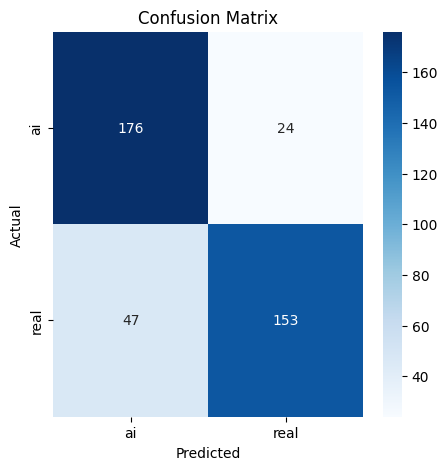

In [17]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.classes,
            yticklabels=test_data.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## **10. Misclassified Images**

Even with high accuracy, a model may still make mistakes. Visualizing misclassified images helps identifying patterns in errors,understanding which classes are confusedand gaining insights for improving data preprocessing, augmentation or model design.

Total misclassified samples: 71


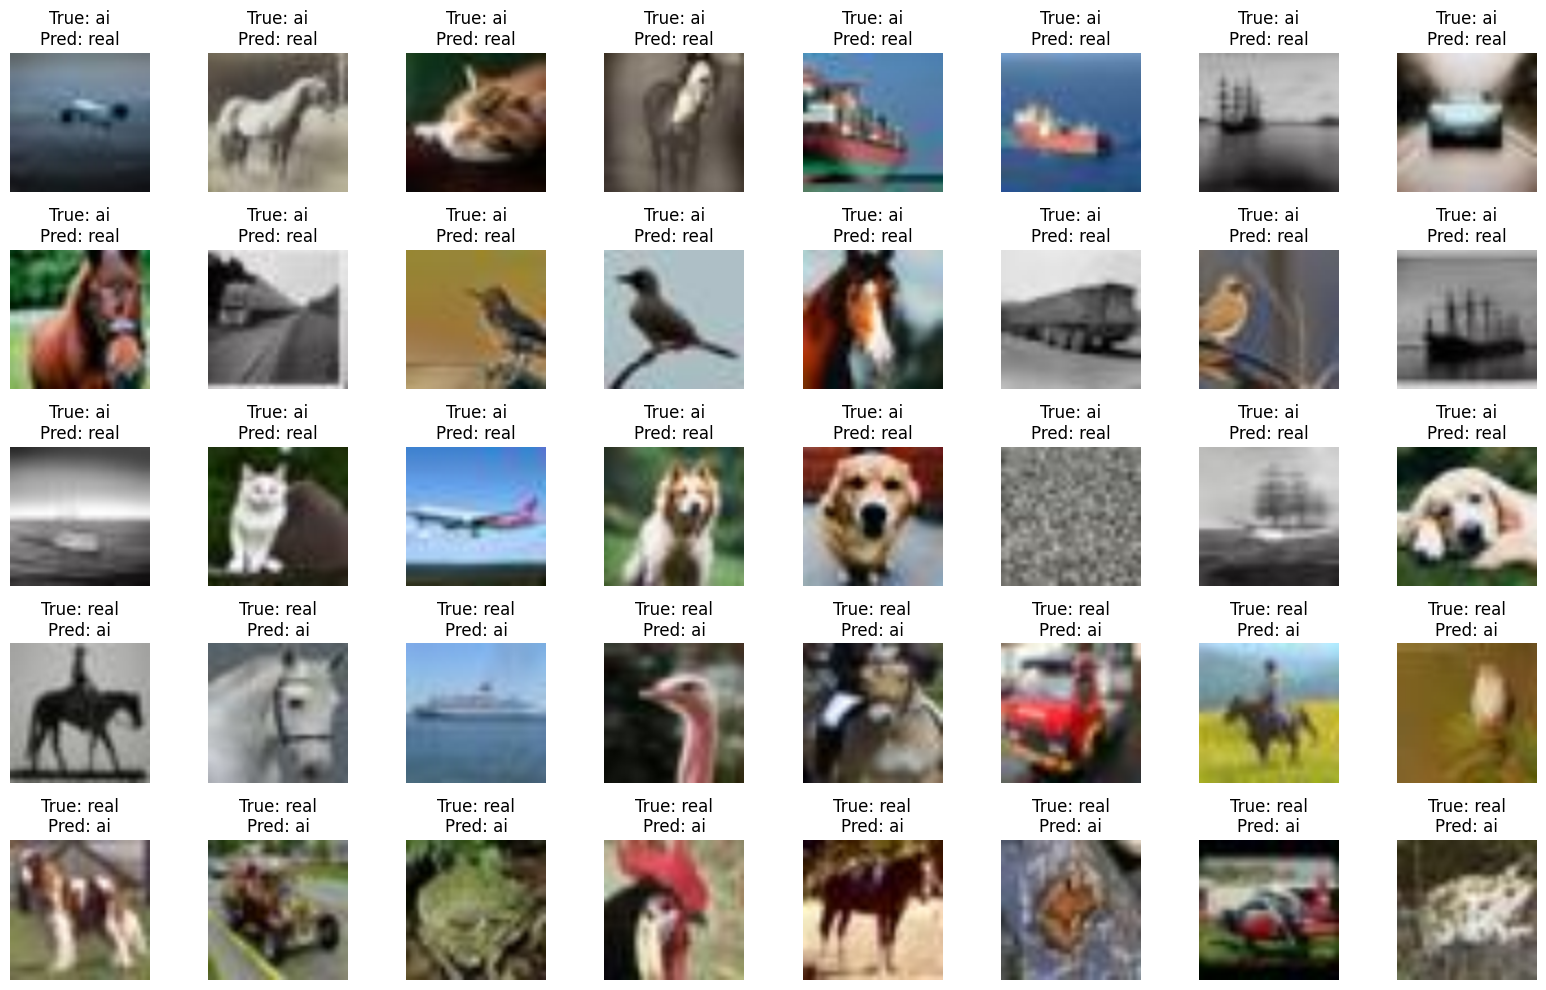

In [18]:
misclassified = []

# Collect misclassified samples
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    for img, true, pred in zip(images, labels, preds):
        if true != pred:
            misclassified.append((img.cpu(), true.cpu(), pred.cpu()))

print(f"Total misclassified samples: {len(misclassified)}")

# Define class names (replace with your actual classes if not using ImageFolder)
class_names = train_loader.dataset.classes  # or manually define your classes

# Function to denormalize images
def denormalize(img, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]):
    img = img.clone()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    return img

# Display misclassified images
num_rows = 5
num_cols = 8
num_to_show = num_rows * num_cols
num_to_show = min(num_to_show, len(misclassified))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols*2, num_rows*2))
axes = axes.flatten()  # flatten for easy iteration

for idx in range(num_to_show):
    img, true, pred = misclassified[idx]
    img = denormalize(img)             # denormalize before plotting
    img = img.permute(1, 2, 0)         # CxHxW -> HxWxC
    img = torch.clamp(img, 0, 1)       # ensure values are between 0 and 1
    axes[idx].imshow(img)
    axes[idx].set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
    axes[idx].axis('off')

# Turn off any unused subplots
for idx in range(num_to_show, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## **11. Visualization (Loss & Accuracy)**

Plotting accuracy and loss curves helps track the model’s learning progress over epochs. These visualizations can reveal:


*   How quickly the model is learning.
*   Whether the model is overfitting or underfitting.


*   Trends that guide hyperparameter tuning or early stopping decisions.




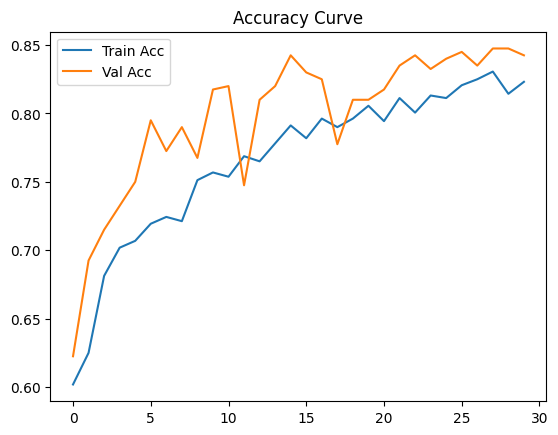

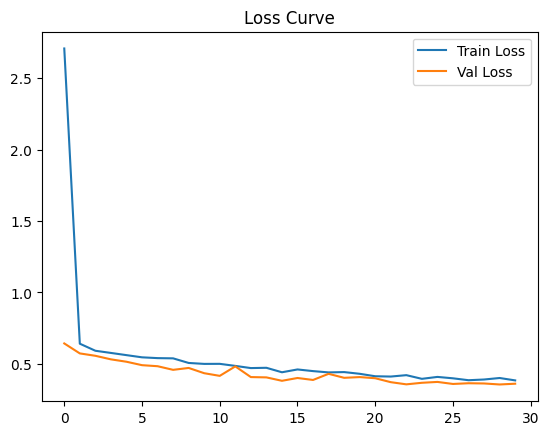

In [19]:
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

## **12. Analysis & Discussion**

The model incorporating Batch Normalization and Dropout demonstrates better generalization compared to a simple CNN, as regularization techniques prevent overfitting; without them, training accuracy may be high, but validation accuracy drops significantly. Per-class analysis from the confusion matrix indicates that AI-generated images tend to be misclassified more often than real images, likely because high-quality AI images are highly realistic and harder to distinguish, whereas real images exhibit more consistent natural textures. This suggests that the model primarily learns texture-based patterns rather than semantic content, which explains why it struggles with distinguishing subtle differences in high-fidelity AI images, highlighting the importance of regularization and careful evaluation of class-specific performance.




In [20]:
print(f"Best Val Loss: {min(val_losses):.4f}")
print(f"Best Val Accuracy: {max(val_accs)*100:.2f}%")

Best Val Loss: 0.3554
Best Val Accuracy: 84.75%


In [24]:
total_params = sum(p.numel() for p in model.parameters())
print("Total Parameters:", total_params)

Total Parameters: 8483074


## **13. Save Model**

In [21]:
torch.save(model.state_dict(), "ai_vs_real_model.pth")

## **14. Conclusion & Future Work**


The study achieved strong classification performance on the AI vs. Real image dataset, with regularization techniques like BatchNorm and Dropout significantly improving model generalization, allowing it to effectively distinguish patterns between synthetic and real images. For future work, performance can be further enhanced by leveraging transfer learning with architectures such as ResNet or EfficientNet, increasing dataset diversity, applying explainability methods like Grad-CAM to understand model decisions, and performing detailed hyperparameter tuning to achieve higher accuracy and robustness.

In [22]:
from google.colab import files
files.download('ai_vs_real_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>